# Synthetic Model Generator

- define mesh & discretization
- define topography
- define earth vs air
- define density map

In [13]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from discretize import TensorMesh
from discretize.utils import active_from_xyz
from simpeg.utils import plot2Ddata, model_builder
from simpeg.potential_fields import gravity
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils,
)

### define tensor mesh (a SIMPEG util)

In [14]:
dh = 5.0
hx = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hy = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hz = [(dh, 5, -1.3), (dh, 15)]
mesh = TensorMesh([hx, hy, hz], "CCN")

### define & generate topography

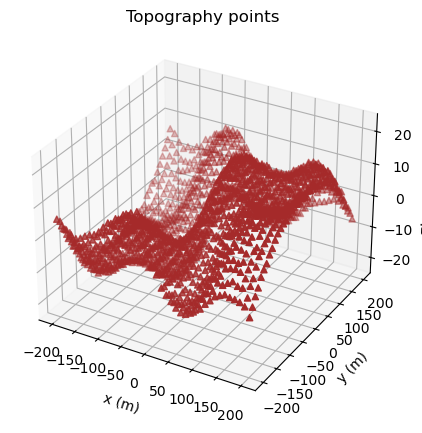

In [15]:
def synthetic_topography(
    x_min=-200, x_max=200,
    y_min=-200, y_max=200,
    dx=10, dy=10,
    base_level=0.0,
    fbm_amp=20.0,
    seed=0,
    noise_sigma=0.5,
    scatter_fraction=0.0,
):
    """
    Return (N,3) array of x,y,z points representing synthetic topography.

    Parameters
    ----------
    x_min, x_max, y_min, y_max : float
        Domain bounds.
    dx, dy : float
        Sampling grid spacing.
    base_level : float
        Base elevation (meters).
    fbm_amp : float
        Relief amplitude (meters).
    seed : int
        RNG seed.
    noise_sigma : float
        Std deviation of Gaussian noise on z.
    scatter_fraction : float
        Fraction of points randomly dropped (0–1).

    Returns
    -------
    xyz : ndarray, shape (N,3)
        Point cloud of synthetic topography.
    """
    rng = np.random.default_rng(seed)

    xs = np.arange(x_min, x_max + 1e-9, dx)
    ys = np.arange(y_min, y_max + 1e-9, dy)
    X, Y = np.meshgrid(xs, ys, indexing="xy")

    # synthetic hills from sinusoids
    Z = base_level + fbm_amp * (
        np.sin(0.01*X + seed) * np.cos(0.01*Y + seed/2)
        + 0.5*np.sin(0.03*X) * np.cos(0.02*Y)
    )

    # add noise
    Z += rng.normal(0.0, noise_sigma, size=Z.shape)

    # flatten
    XX, YY, ZZ = X.ravel(), Y.ravel(), Z.ravel()

    # optional subsample to simulate scattered points
    if scatter_fraction > 0:
        keep = rng.random(XX.size) > scatter_fraction
        XX, YY, ZZ = XX[keep], YY[keep], ZZ[keep]

    return np.c_[XX, YY, ZZ]

# Plot
topo = synthetic_topography()

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(topo[:,0], topo[:,1], topo[:,2], c='brown', marker='^')
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("Elevation (m)")
ax.set_title("Topography points")
plt.show()

### define cells

- earth vs air
- density map

In [16]:

# Find the indices of the active cells in forward model (ones below surface)
ind_active = active_from_xyz(mesh, topo)

# Define mapping from model to active cells
nC = int(ind_active.sum())
model_map = maps.IdentityMap(nP=nC)  # model consists of a value for each active cell

# Define and plot starting model
starting_model = np.zeros(nC)

# Define density contrast values for each unit in g/cc
background_density = 0.0
block_density = -0.2
sphere_density = 0.2

# Define model. Models in SimPEG are vector arrays.
true_model = background_density * np.ones(nC)

# You could find the indicies of specific cells within the model and change their
# value to add structures.
ind_block = (
    (mesh.gridCC[ind_active, 0] > -50.0)
    & (mesh.gridCC[ind_active, 0] < -20.0)
    & (mesh.gridCC[ind_active, 1] > -15.0)
    & (mesh.gridCC[ind_active, 1] < 15.0)
    & (mesh.gridCC[ind_active, 2] > -50.0)
    & (mesh.gridCC[ind_active, 2] < -30.0)
)
true_model[ind_block] = block_density

# You can also use SimPEG utilities to add structures to the model more concisely
ind_sphere = model_builder.get_indices_sphere(
    np.r_[35.0, 0.0, -40.0], 15.0, mesh.gridCC
)
ind_sphere = ind_sphere[ind_active]
true_model[ind_sphere] = sphere_density

# 

### Plot

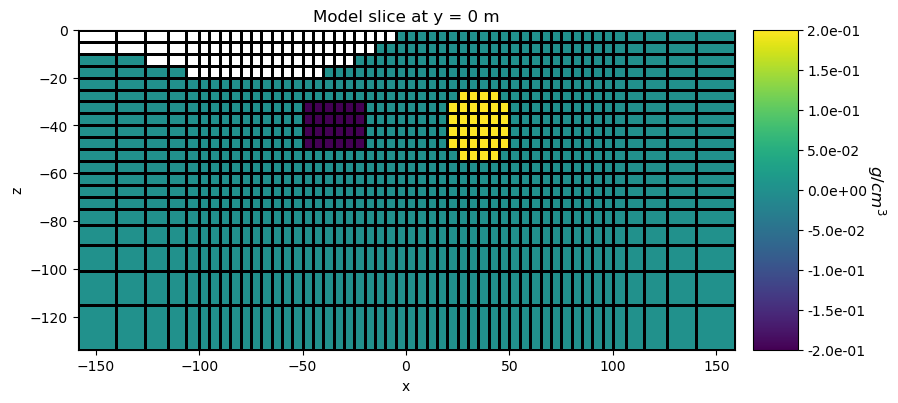

In [18]:
# Plot True Model
fig = plt.figure(figsize=(9, 4))
plotting_map = maps.InjectActiveCells(mesh, ind_active, np.nan)

ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])
mesh.plot_slice(
    plotting_map * true_model,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=True,
    clim=(np.min(true_model), np.max(true_model)),
    pcolor_opts={"cmap": "viridis"},
)
ax1.set_title("Model slice at y = 0 m")


ax2 = fig.add_axes([0.85, 0.1, 0.05, 0.8])
norm = mpl.colors.Normalize(vmin=np.min(true_model), vmax=np.max(true_model))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.viridis, format="%.1e"
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=12)

plt.show()

### Forward Solver